# **Aim of the Study**

To develop an interpretable fuzzy/neuro-fuzzy inspired hybrid system for heart disease risk prediction that demonstrates competitive performance against baseline models while simultaneously providing human-readable rules.

# **Phase 1: Data Understanding and Preprocessing**

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
#Feature Grouping
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
print(type(y))
print(y.head())

<class 'pandas.core.frame.DataFrame'>
   num
0    0
1    2
2    1
3    0
4    0


In [ ]:
y = y.squeeze()

In [ ]:
df = X.copy()
df["target"] = y

print(df.shape)
print(df.head())

(303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       2  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0  


In [ ]:
df["target"] = (df["target"] > 0).astype(int)

In [ ]:
print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [ ]:
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

target
0    164
1    139
Name: count, dtype: int64
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [ ]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [ ]:
df = df.replace("?", np.nan)

In [ ]:
df = df.apply(pd.to_numeric, errors="ignore")

/tmp/ipykernel_6544/3400095637.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [ ]:
X = df.drop(columns=["target"])
y = df["target"]

In [ ]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  
0        3  0.0   6.0  
1        2  3.0   3.0  
2        2  2.0

In [ ]:
print(y)

0      0
1      1
2      1
3      0
4      0
      ..
298    1
299    1
300    1
301    1
302    0
Name: target, Length: 303, dtype: int64


# **Phase 2: EDA (Exploratory Data Analysis)**

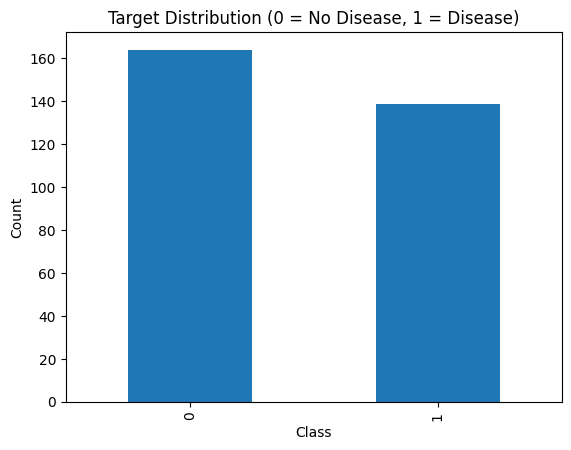

In [ ]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Target Distribution (0 = No Disease, 1 = Disease)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

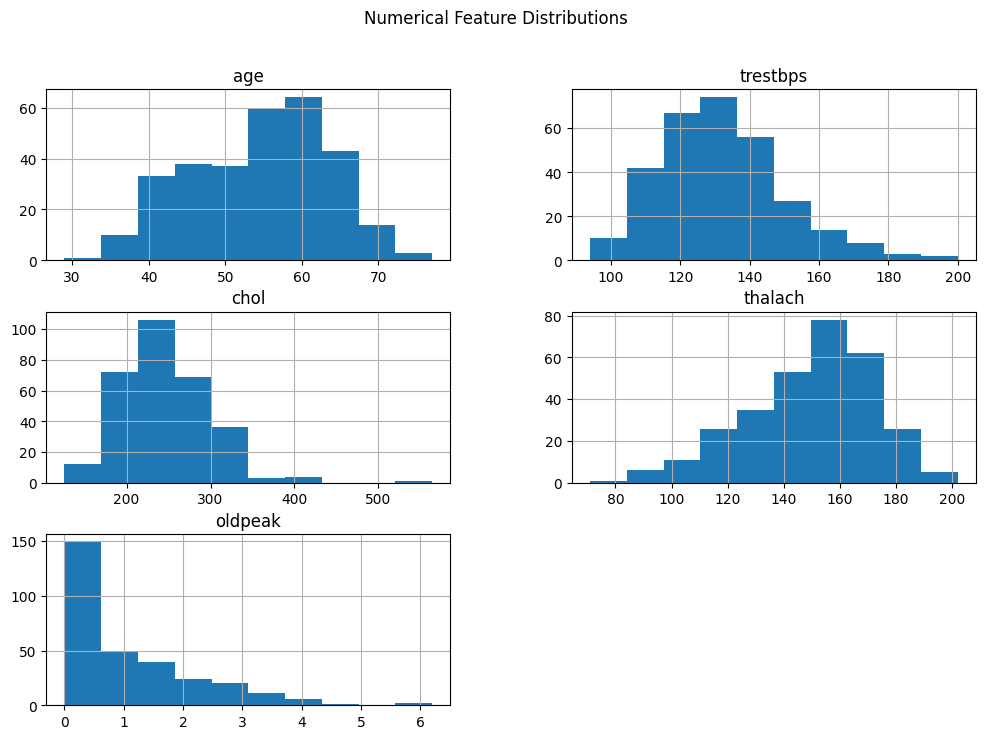

In [ ]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

X[numerical_features].hist(figsize=(12,8))
plt.suptitle("Numerical Feature Distributions")
plt.show()

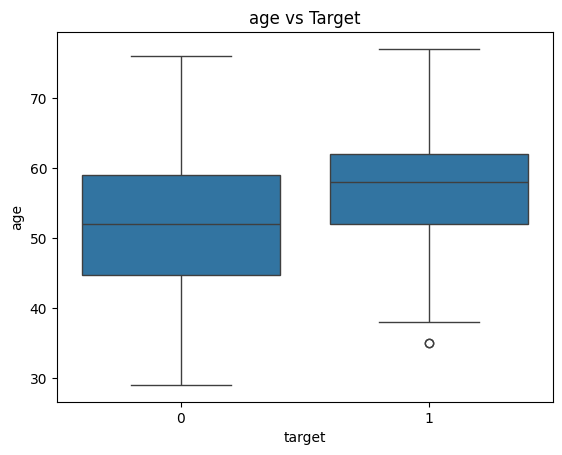

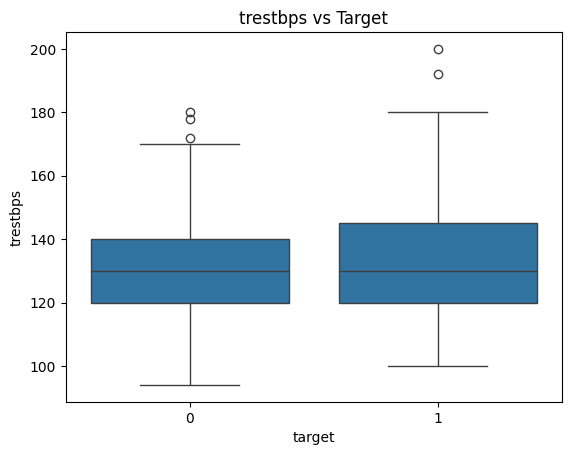

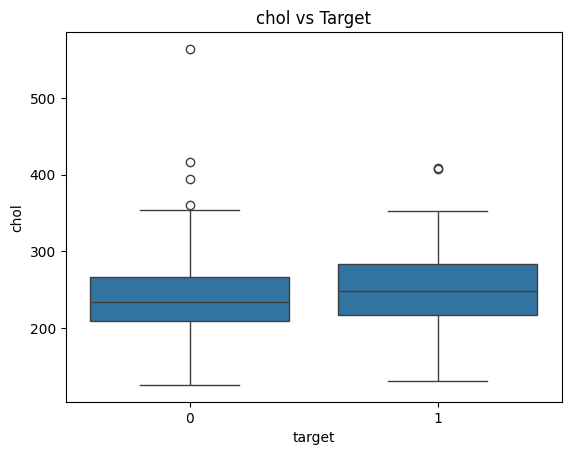

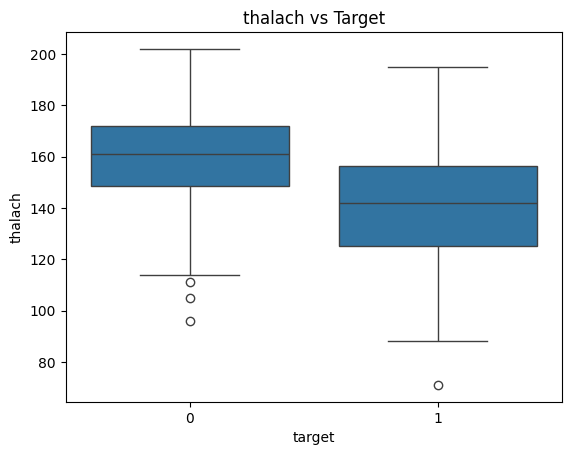

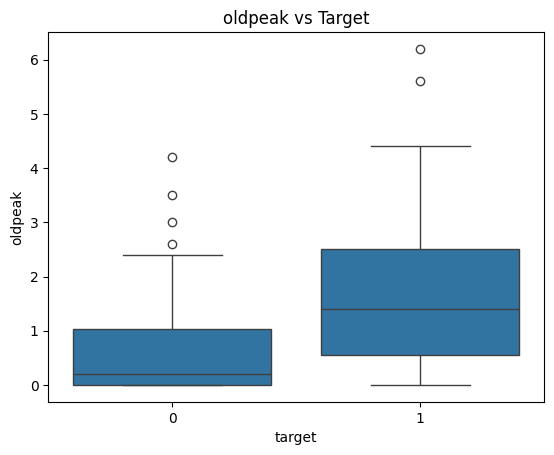

In [ ]:
import seaborn as sns

for col in numerical_features:
    plt.figure()
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} vs Target")
    plt.show()

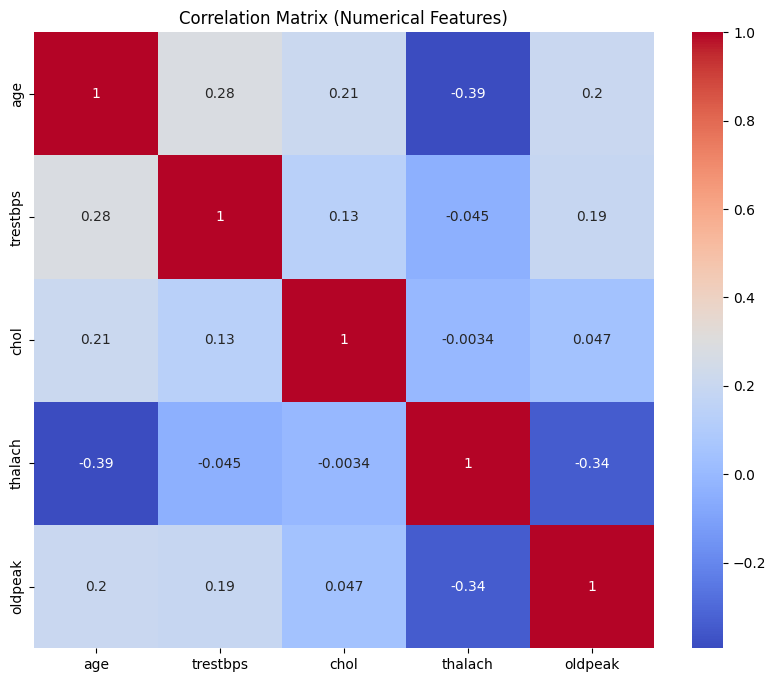

In [ ]:
import numpy as np

plt.figure(figsize=(10,8))
sns.heatmap(X[numerical_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

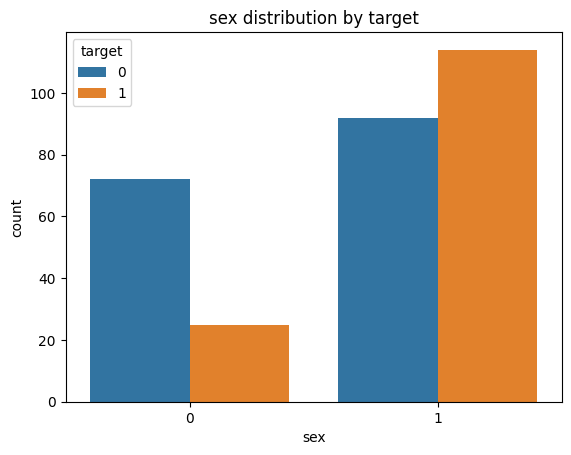

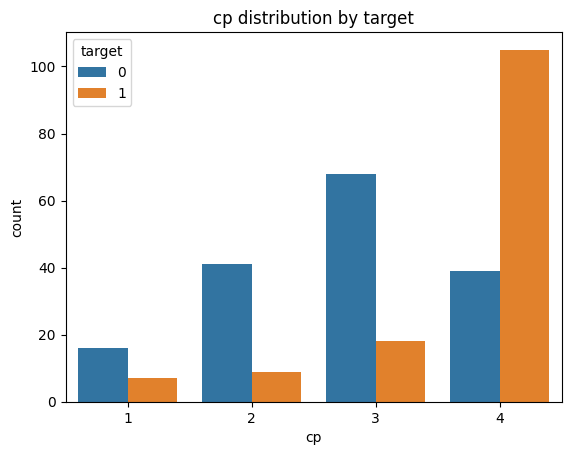

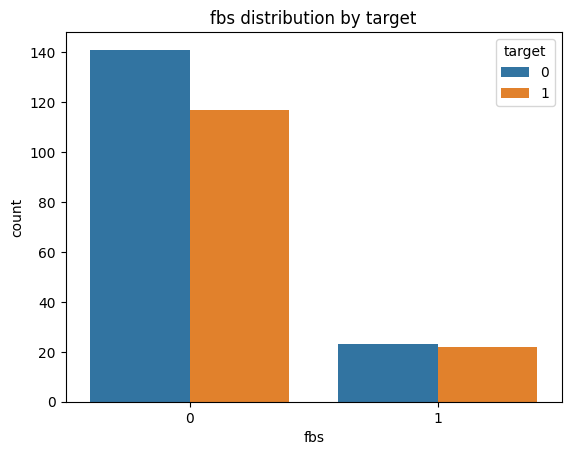

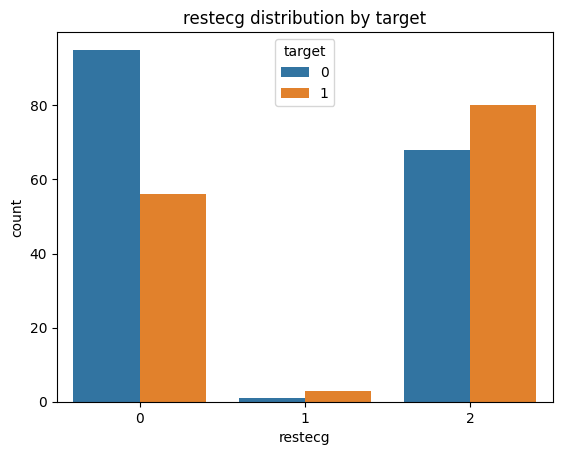

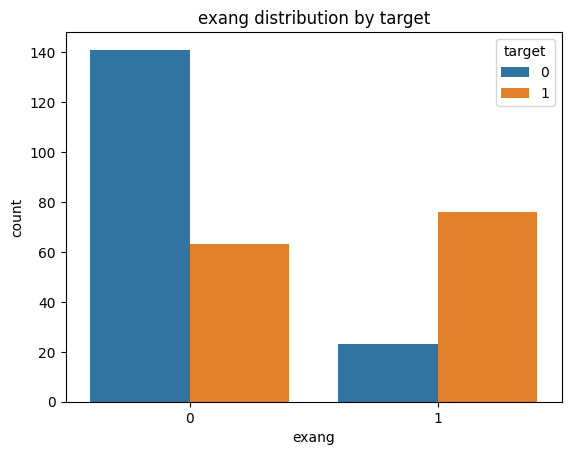

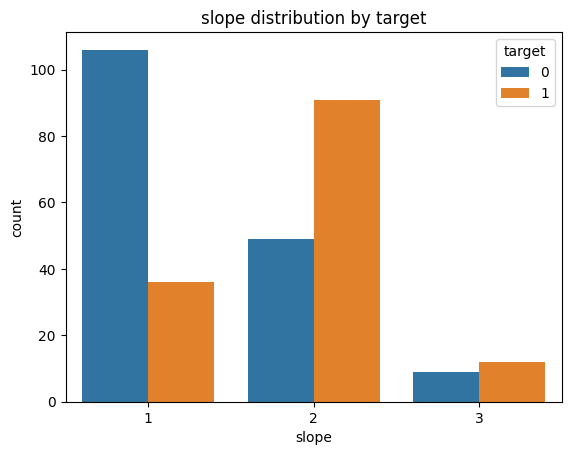

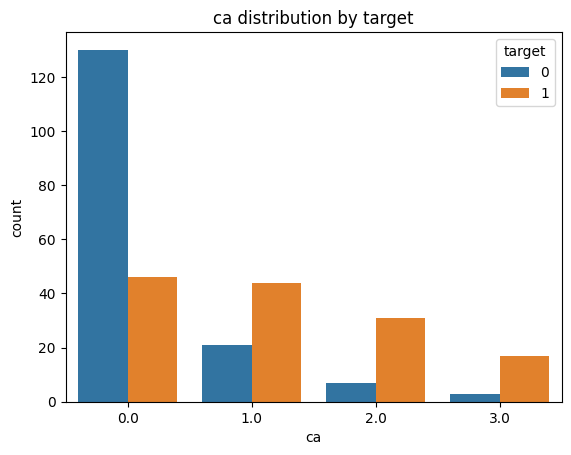

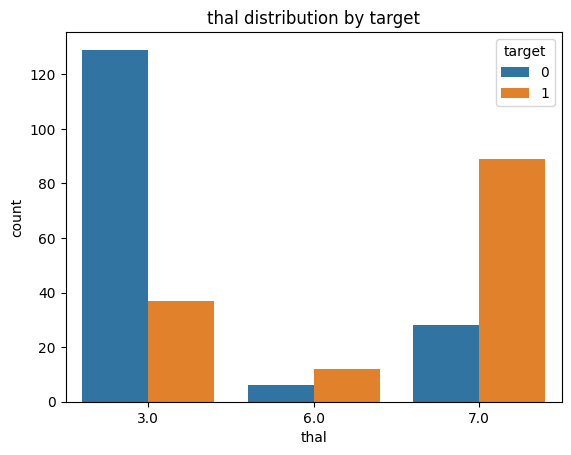

In [ ]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for col in categorical_features:
    plt.figure()
    sns.countplot(x=X[col], hue=y)
    plt.title(f"{col} distribution by target")
    plt.show()

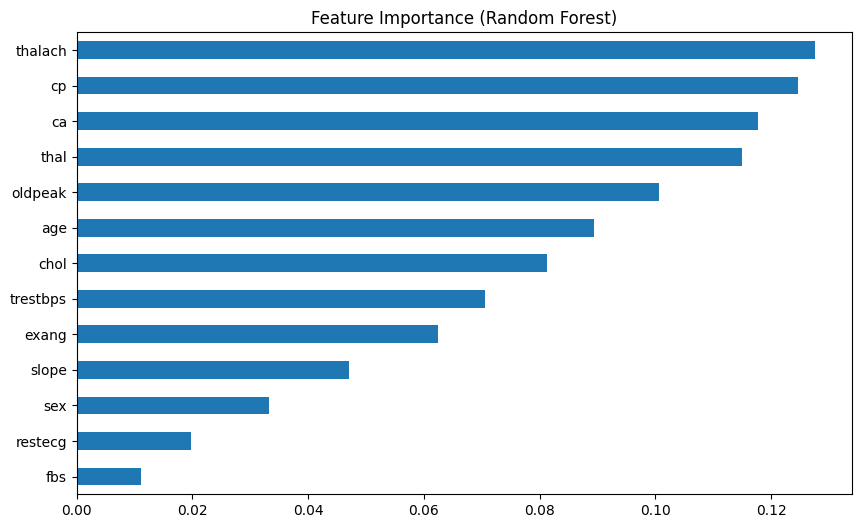

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X.fillna(X.median()), y)

importances = rf.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.show()

*Exploratory data analysis revealed that features such as maximum heart rate (thalach), ST depression (oldpeak), chest pain type (cp), number of vessels (ca), and thalassemia (thal) are the most discriminative variables for heart disease prediction.*

*In particular, lower thalach and higher oldpeak values are strongly associated with the presence of disease. These findings guided the design of fuzzy membership functions and rule-based reasoning in later stages of our project.*

# **Phase 3: Baseline Models**

*Quick Summary*

**Models:** Logistic Regression, Random Forest, MLP

**Metrics:** Accuracy, Precision, Recall, F1-score, ROC-AUC

**Evaluation Method:** Stratified K-Fold Cross-Validation

*In this phase, we establish baseline ML models to evaluate how well traditional classifiers perform on the heart disease dataset. These baselines will serve as reference points for later comparison with the fuzzy and hybrid models.*

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

*Here, we define a reusable preprocessing pipeline so that all transformations are applied consistently within cross-validation. This ensures a fair and leakage-free comparison across baseline models.*

In [ ]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

*We use stratified 5-fold cross-validation to evaluate each model. Multiple metrics are reported to provide a more complete picture of model performance beyond accuracy alone.*

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

*Logistic Regressesion -> linear baseline*

*Random Forest -> tree based ensemble baseline*

*MLP -> neural network baseline*

In [ ]:
baseline_models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),

    "MLP": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42))
    ])
}

In [ ]:
results = []

for model_name, model in baseline_models.items():
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    results.append({
        "Model": model_name,
        "Accuracy": np.mean(cv_results["test_accuracy"]),
        "Precision": np.mean(cv_results["test_precision"]),
        "Recall": np.mean(cv_results["test_recall"]),
        "F1-score": np.mean(cv_results["test_f1"]),
        "ROC-AUC": np.mean(cv_results["test_roc_auc"])
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.854699,0.874430,0.797884,0.833226,0.918796
1,Random Forest,0.844918,0.857438,0.798413,0.825471,0.917428
2,MLP,0.795355,0.783679,0.769841,0.775092,0.858947


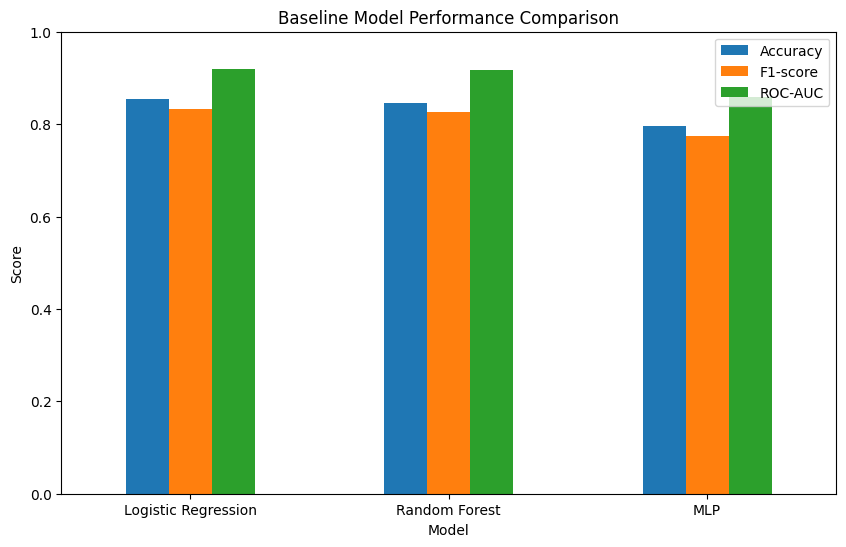

In [ ]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")

plot_df[["Accuracy", "F1-score", "ROC-AUC"]].plot(kind="bar", figsize=(10,6))
plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

*As we can see the results table and bar chart, Logistic Regression achieved the best overall performance with an ROC-AUC of 0.918, slightly outperforming Random Forest. MLP showed lower performance, likely due to the relatively small dataset size. Overall, traditional machine learning models already provide strong predictive performance, establishing a solid baseline for evaluating the proposed hybrid model.*

*Our goal is **not** to outperform all baseline models, but to provide interpretable reasoning while maintaining competitive performance :)*

# **Phase 4: Fuzzy Logic Design**

*In the fuzzy design phase, we select the most informative variables based on the EDA findings. Continuous features such as **oldpeak**, **thalach**, and **age** are modeled using fuzzy membership functions, while categorical clinical indicators such as **cp**, **exang**, **ca**, and **thal** are incorporated into the rule base.*

In [ ]:
!pip install scikit-fuzzy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

*We define fuzzy membership functions for the selected continuous variables. These functions translate numeric feature values into linguistic concepts such as low, medium, and high.*

In [ ]:
fuzzy_features = ["age", "thalach", "oldpeak"]

for col in fuzzy_features:
    print(f"{col}: min={X[col].min()}, max={X[col].max()}, median={X[col].median()}")
    print(X[col].describe())
    print("-" * 50)

age: min=29, max=77, median=56.0
count    303.000000
mean      54.438944
std        9.038662
min       29.000000
25%       48.000000
50%       56.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64
--------------------------------------------------
thalach: min=71, max=202, median=153.0
count    303.000000
mean     149.607261
std       22.875003
min       71.000000
25%      133.500000
50%      153.000000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64
--------------------------------------------------
oldpeak: min=0.0, max=6.2, median=0.8
count    303.000000
mean       1.039604
std        1.161075
min        0.000000
25%        0.000000
50%        0.800000
75%        1.600000
max        6.200000
Name: oldpeak, dtype: float64
--------------------------------------------------


In [ ]:
age_universe = np.arange(25, 81, 1)
thalach_universe = np.arange(70, 211, 1)
oldpeak_universe = np.arange(0, 6.6, 0.1)

In [ ]:
#Defining membership functions
age_young = fuzz.trimf(age_universe, [25, 30, 45])
age_middle = fuzz.trimf(age_universe, [40, 55, 70])
age_old = fuzz.trimf(age_universe, [60, 75, 80])

thalach_low = fuzz.trimf(thalach_universe, [70, 90, 130])
thalach_medium = fuzz.trimf(thalach_universe, [120, 145, 170])
thalach_high = fuzz.trimf(thalach_universe, [150, 180, 210])

oldpeak_low = fuzz.trapmf(oldpeak_universe, [0, 0, 0.5, 1.2])
oldpeak_medium = fuzz.trimf(oldpeak_universe, [0.8, 1.5, 2.5])
oldpeak_high = fuzz.trapmf(oldpeak_universe, [2.0, 3.0, 6.5, 6.5])

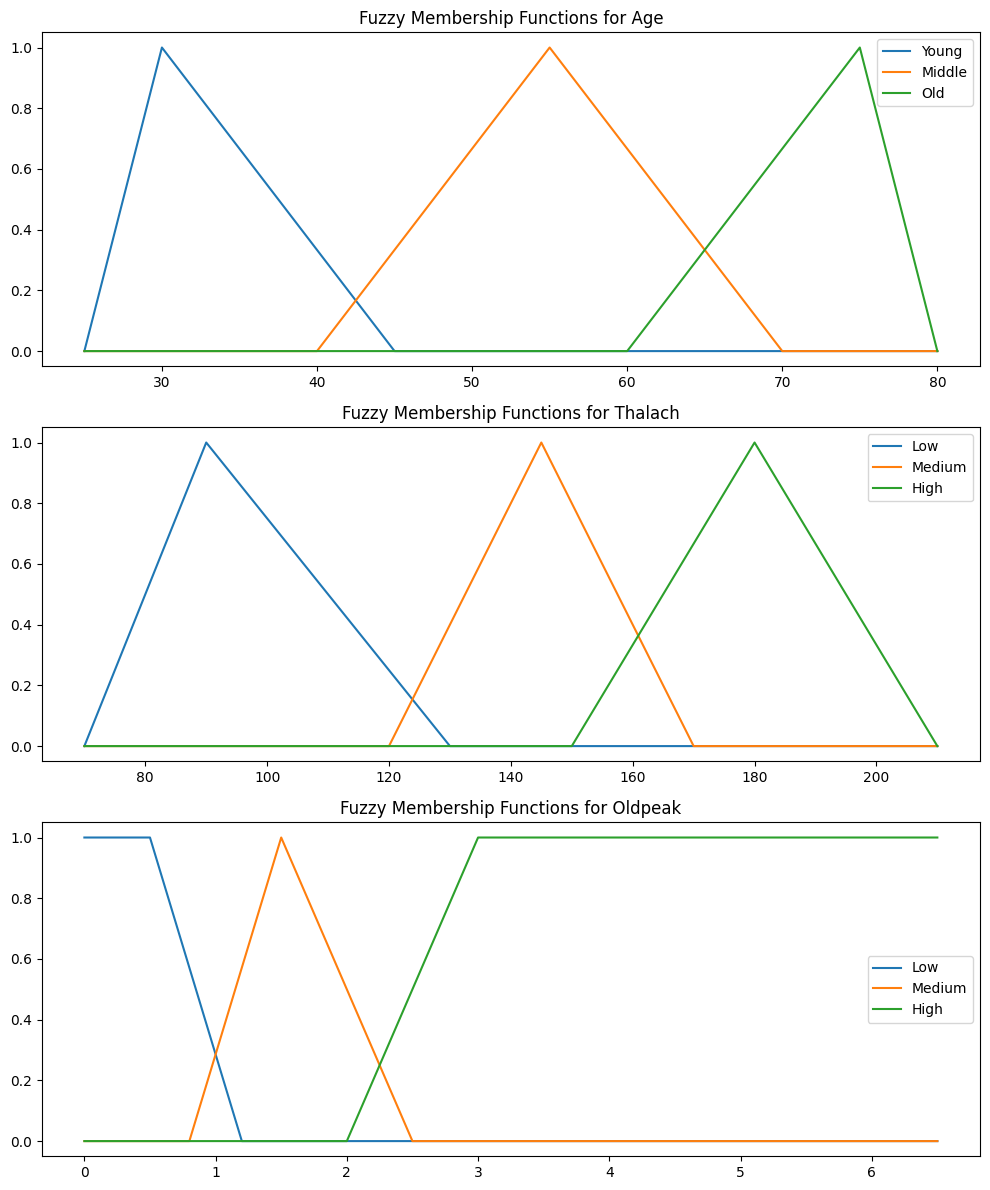

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

#Age
axes[0].plot(age_universe, age_young, label="Young")
axes[0].plot(age_universe, age_middle, label="Middle")
axes[0].plot(age_universe, age_old, label="Old")
axes[0].set_title("Fuzzy Membership Functions for Age")
axes[0].legend()

#Thalach
axes[1].plot(thalach_universe, thalach_low, label="Low")
axes[1].plot(thalach_universe, thalach_medium, label="Medium")
axes[1].plot(thalach_universe, thalach_high, label="High")
axes[1].set_title("Fuzzy Membership Functions for Thalach")
axes[1].legend()

#Oldpeak
axes[2].plot(oldpeak_universe, oldpeak_low, label="Low")
axes[2].plot(oldpeak_universe, oldpeak_medium, label="Medium")
axes[2].plot(oldpeak_universe, oldpeak_high, label="High")
axes[2].set_title("Fuzzy Membership Functions for Oldpeak")
axes[2].legend()

plt.tight_layout()
plt.show()

*To illustrate how fuzzy logic works, we calculate the degree of membership of a sample patient across the defined fuzzy sets.*

In [ ]:
sample_age = 60
sample_thalach = 130
sample_oldpeak = 2.2

age_young_degree = fuzz.interp_membership(age_universe, age_young, sample_age)
age_middle_degree = fuzz.interp_membership(age_universe, age_middle, sample_age)
age_old_degree = fuzz.interp_membership(age_universe, age_old, sample_age)

thalach_low_degree = fuzz.interp_membership(thalach_universe, thalach_low, sample_thalach)
thalach_medium_degree = fuzz.interp_membership(thalach_universe, thalach_medium, sample_thalach)
thalach_high_degree = fuzz.interp_membership(thalach_universe, thalach_high, sample_thalach)

oldpeak_low_degree = fuzz.interp_membership(oldpeak_universe, oldpeak_low, sample_oldpeak)
oldpeak_medium_degree = fuzz.interp_membership(oldpeak_universe, oldpeak_medium, sample_oldpeak)
oldpeak_high_degree = fuzz.interp_membership(oldpeak_universe, oldpeak_high, sample_oldpeak)

print("Age memberships:")
print("Young:", age_young_degree)
print("Middle:", age_middle_degree)
print("Old:", age_old_degree)

print("\nThalach memberships:")
print("Low:", thalach_low_degree)
print("Medium:", thalach_medium_degree)
print("High:", thalach_high_degree)

print("\nOldpeak memberships:")
print("Low:", oldpeak_low_degree)
print("Medium:", oldpeak_medium_degree)
print("High:", oldpeak_high_degree)

Age memberships:
Young: 0.0
Middle: 0.6666666666666666
Old: 0.0

Thalach memberships:
Low: 0.0
Medium: 0.4
High: 0.0

Oldpeak memberships:
Low: 0.0
Medium: 0.2999999999999998
High: 0.20000000000000018


*Based on the EDA findings, we define an initial fuzzy rule base that reflects clinically meaningful and data-driven patterns associated with heart disease risk.*

1. IF oldpeak is high THEN risk is high
2. IF thalach is low THEN risk is high
3. IF oldpeak is high AND thalach is low THEN risk is very high
4. IF age is old AND oldpeak is medium/high THEN risk is high
5. IF thalach is high AND oldpeak is low THEN risk is low
6. IF cp = 4 THEN risk is high
7. IF exang = 1 THEN risk is high
8. IF ca >= 2 THEN risk is high
9. IF thal = 7 THEN risk is high



*Initial fuzzy rules were derived from EDA findings.*

*For example, high oldpeak, low thalach, and abnormal clinical indicators such as exang = 1, high ca, and thal = 7 were associated with increased risk. These rules form the basis of the interpretable reasoning component of the proposed system.*

In [ ]:
#Risk Mapping
#linguistic -> numeric
risk_values = {
    "low": 0.2,
    "medium": 0.5,
    "high": 0.8,
    "very_high": 1.0
}

In [ ]:
#Fuzzy inference function
def compute_fuzzy_risk(age, thalach, oldpeak, cp, exang, ca, thal):

    #Membership degrees
    age_middle_degree = fuzz.interp_membership(age_universe, age_middle, age)
    age_old_degree = fuzz.interp_membership(age_universe, age_old, age)

    thalach_low_degree = fuzz.interp_membership(thalach_universe, thalach_low, thalach)
    thalach_medium_degree = fuzz.interp_membership(thalach_universe, thalach_medium, thalach)
    thalach_high_degree = fuzz.interp_membership(thalach_universe, thalach_high, thalach)

    oldpeak_low_degree = fuzz.interp_membership(oldpeak_universe, oldpeak_low, oldpeak)
    oldpeak_medium_degree = fuzz.interp_membership(oldpeak_universe, oldpeak_medium, oldpeak)
    oldpeak_high_degree = fuzz.interp_membership(oldpeak_universe, oldpeak_high, oldpeak)

    #Rule activations
    rules = []

    #Rule 1: oldpeak high -> high risk
    rules.append((oldpeak_high_degree, risk_values["high"], "Oldpeak is high"))

    #Rule 2: thalach low -> high risk
    rules.append((thalach_low_degree, risk_values["high"], "Thalach is low"))

    #Rule 3: oldpeak high AND thalach low -> very high risk
    rule3_activation = min(oldpeak_high_degree, thalach_low_degree)
    rules.append((rule3_activation, risk_values["very_high"], "Oldpeak is high AND Thalach is low"))

    #Rule 4: age old AND oldpeak medium/high -> high risk
    rule4_activation = min(age_old_degree, max(oldpeak_medium_degree, oldpeak_high_degree))
    rules.append((rule4_activation, risk_values["high"], "Age is old AND Oldpeak is elevated"))

    #Rule 5: thalach high AND oldpeak low -> low risk
    rule5_activation = min(thalach_high_degree, oldpeak_low_degree)
    rules.append((rule5_activation, risk_values["low"], "Thalach is high AND Oldpeak is low"))

    #Rule 6: cp = 4 -> high risk
    if cp == 4:
        rules.append((1.0, risk_values["high"], "Chest pain type = 4"))

    #Rule 7: exang = 1 -> high risk
    if exang == 1:
        rules.append((1.0, risk_values["high"], "Exercise-induced angina = 1"))

    #Rule 8: ca >= 2 -> high risk
    if ca >= 2:
        rules.append((1.0, risk_values["high"], "Number of vessels (ca) >= 2"))

    #Rule 9: thal = 7 -> high risk
    if thal == 7:
        rules.append((1.0, risk_values["high"], "Thal = 7"))

    # Medium risk rules ( we explored some errors while testing patiens :) )

    #Rule 10: oldpeak medium -> medium risk
    rules.append((oldpeak_medium_degree, risk_values["medium"], "Oldpeak is medium"))

    #Rule 11: thalach medium -> medium risk
    rules.append((thalach_medium_degree, risk_values["medium"], "Thalach is medium"))

    #Rule 12: age middle AND oldpeak medium -> medium risk
    rule12_activation = min(age_middle_degree, oldpeak_medium_degree)
    rules.append((rule12_activation, risk_values["medium"], "Age middle AND Oldpeak medium"))

    #Rule 13: cp = 2 or 3 -> medium risk
    if cp in [2, 3]:
      rules.append((1.0, risk_values["medium"], "Chest pain type = 2 or 3"))

    #Rule 14: ca = 1 -> medium risk
    if ca == 1:
      rules.append((1.0, risk_values["medium"], "Number of vessels (ca) = 1"))

    #Rule 15: thal = 6 -> medium risk
    if thal == 6:
      rules.append((1.0, risk_values["medium"], "Thal = 6"))

    #Aggregate risk score
    numerator = 0
    denominator = 0
    explanations = []

    for activation, risk_value, description in rules:
        if activation > 0:
            numerator += activation * risk_value
            denominator += activation
            explanations.append((description, activation))

    final_risk = numerator / denominator if denominator > 0 else 0.0

    return final_risk, explanations

In [ ]:
risk, explanations = compute_fuzzy_risk(
    age=60,
    thalach=130,
    oldpeak=2.2,
    cp=4,
    exang=1,
    ca=2,
    thal=7
)

print(f"Final Risk Score: {risk:.4f}")
print("\nActivated Rules:")
for desc, act in explanations:
    print(f"- {desc} -> activation: {act:.3f}")

Final Risk Score: 0.7423

Activated Rules:
- Oldpeak is high -> activation: 0.200
- Chest pain type = 4 -> activation: 1.000
- Exercise-induced angina = 1 -> activation: 1.000
- Number of vessels (ca) >= 2 -> activation: 1.000
- Thal = 7 -> activation: 1.000
- Oldpeak is medium -> activation: 0.300
- Thalach is medium -> activation: 0.400
- Age middle AND Oldpeak medium -> activation: 0.300


*The fuzzy inference example produced a high risk score for the sample patient. This result is consistent with the rule base, since several high-risk conditions were activated simultaneously, including abnormal chest pain type, exercise-induced angina, increased number of affected vessels, and abnormal thal status. The example demonstrates that the fuzzy system can provide both a quantitative risk score and an interpretable explanation of the decision.*

In [ ]:
sample_patients = [
    {
        "label": "Low-risk example",
        "age": 45,
        "thalach": 180,
        "oldpeak": 0.2,
        "cp": 3,
        "exang": 0,
        "ca": 0,
        "thal": 3
    },
    {
        "label": "Moderate-risk example",
        "age": 58,
        "thalach": 145,
        "oldpeak": 1.6,
        "cp": 2,
        "exang": 0,
        "ca": 1,
        "thal": 6
    },
    {
        "label": "High-risk example",
        "age": 60,
        "thalach": 130,
        "oldpeak": 2.2,
        "cp": 4,
        "exang": 1,
        "ca": 2,
        "thal": 7
    }
]

for patient in sample_patients:
    risk, explanations = compute_fuzzy_risk(
        age=patient["age"],
        thalach=patient["thalach"],
        oldpeak=patient["oldpeak"],
        cp=patient["cp"],
        exang=patient["exang"],
        ca=patient["ca"],
        thal=patient["thal"]
    )

    print("=" * 60)
    print(patient["label"])
    print(f"Final Risk Score: {risk:.4f}")
    print("Activated Rules:")
    for desc, act in explanations:
        print(f"- {desc} -> activation: {act:.3f}")

Low-risk example
Final Risk Score: 0.3500
Activated Rules:
- Thalach is high AND Oldpeak is low -> activation: 1.000
- Chest pain type = 2 or 3 -> activation: 1.000
Moderate-risk example
Final Risk Score: 0.5000
Activated Rules:
- Oldpeak is medium -> activation: 0.900
- Thalach is medium -> activation: 1.000
- Age middle AND Oldpeak medium -> activation: 0.800
- Chest pain type = 2 or 3 -> activation: 1.000
- Number of vessels (ca) = 1 -> activation: 1.000
- Thal = 6 -> activation: 1.000
High-risk example
Final Risk Score: 0.7423
Activated Rules:
- Oldpeak is high -> activation: 0.200
- Chest pain type = 4 -> activation: 1.000
- Exercise-induced angina = 1 -> activation: 1.000
- Number of vessels (ca) >= 2 -> activation: 1.000
- Thal = 7 -> activation: 1.000
- Oldpeak is medium -> activation: 0.300
- Thalach is medium -> activation: 0.400
- Age middle AND Oldpeak medium -> activation: 0.300


*When we had some problems to find appropriate values for different patiens, we learned a lesson: A good fuzzy system is not just about strong rules, but about covering all possible cases.*

**:)**

# **Phase 5: Fuzzy Scoring**

*In this phase, we apply the fuzzy inference system to every patient record in the dataset and generate a fuzzy risk score. This allows us to analyze whether the proposed interpretable fuzzy component captures meaningful signal related to heart disease.*

In [ ]:
fuzzy_scores = []
rule_counts = []

for _, row in df.iterrows():
    risk, explanations = compute_fuzzy_risk(
        age=row["age"],
        thalach=row["thalach"],
        oldpeak=row["oldpeak"],
        cp=row["cp"],
        exang=row["exang"],
        ca=row["ca"],
        thal=row["thal"]
    )

    fuzzy_scores.append(risk)
    rule_counts.append(len(explanations))

df["fuzzy_risk_score"] = fuzzy_scores
df["activated_rule_count"] = rule_counts

df[["target", "fuzzy_risk_score", "activated_rule_count"]].head()

,target,fuzzy_risk_score,activated_rule_count
0,0,0.555556,6
1,1,0.730990,7
2,1,0.781193,9
3,0,0.650000,2
4,0,0.500000,3


*The fuzzy inference system is executed for each observation, producing a continuous risk score and the number of activated rules. These outputs will help us assess both predictive signal and interpretability coverage across the dataset.*

In [ ]:
print(df["fuzzy_risk_score"].describe())
print("\nActivated rule count summary:")
print(df["activated_rule_count"].describe())

count    303.000000
mean       0.599236
std        0.126741
min        0.200000
25%        0.500000
50%        0.619048
75%        0.702350
max        0.844444
Name: fuzzy_risk_score, dtype: float64

Activated rule count summary:
count    303.000000
mean       4.415842
std        1.844631
min        1.000000
25%        3.000000
50%        4.000000
75%        6.000000
max        9.000000
Name: activated_rule_count, dtype: float64


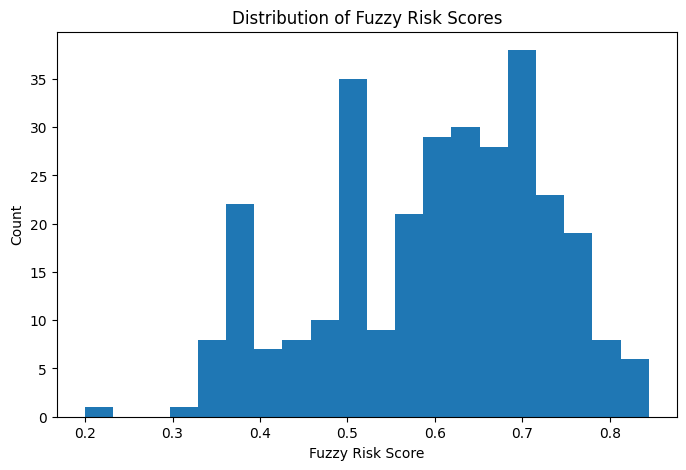

In [ ]:
import matplotlib.pyplot as plt

#Overall distribution
plt.figure(figsize=(8,5))
plt.hist(df["fuzzy_risk_score"], bins=20)
plt.title("Distribution of Fuzzy Risk Scores")
plt.xlabel("Fuzzy Risk Score")
plt.ylabel("Count")
plt.show()

*We compare fuzzy risk scores across the two target classes to evaluate whether higher scores are associated with the presence of heart disease.*

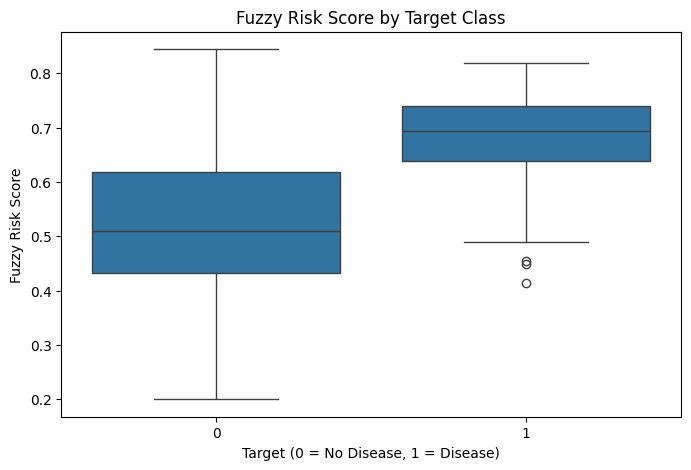

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="fuzzy_risk_score", data=df)
plt.title("Fuzzy Risk Score by Target Class")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Fuzzy Risk Score")
plt.show()

In [ ]:
#Group means comparison
group_summary = df.groupby("target")["fuzzy_risk_score"].agg(["mean", "median", "std", "min", "max"])
group_summary

,mean,median,std,min,max
target,,,,,
0,0.530030,0.510345,0.117734,0.200000,0.844444
1,0.680888,0.694245,0.079835,0.414286,0.819192


*A useful sanity check is to compare the average fuzzy risk score between healthy and diseased patients. A meaningful separation would indicate that the rule-based system captures clinically relevant structure in the data.*

In [ ]:
correlation = df["fuzzy_risk_score"].corr(df["target"])
print(f"Correlation between fuzzy risk score and target: {correlation:.4f}")

Correlation between fuzzy risk score and target: 0.5941


*As a preliminary evaluation, we convert the fuzzy risk score into a binary prediction using a simple threshold. This does not represent the final hybrid model, but helps assess whether the fuzzy component alone carries predictive value.*

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df["fuzzy_pred_05"] = (df["fuzzy_risk_score"] >= 0.5).astype(int)

acc = accuracy_score(df["target"], df["fuzzy_pred_05"])
prec = precision_score(df["target"], df["fuzzy_pred_05"])
rec = recall_score(df["target"], df["fuzzy_pred_05"])
f1 = f1_score(df["target"], df["fuzzy_pred_05"])

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.6370
Precision: 0.5602
Recall   : 0.9712
F1-score : 0.7105


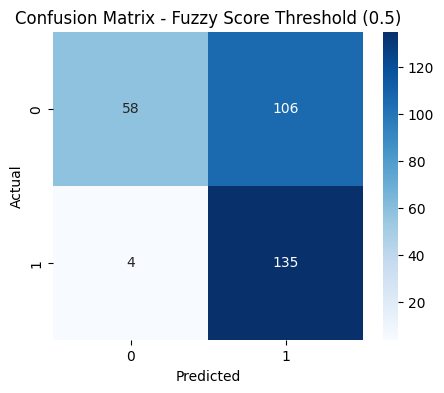

In [ ]:
cm = confusion_matrix(df["target"], df["fuzzy_pred_05"])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Fuzzy Score Threshold (0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

*FP is so high. Which means our system loves to say 'risky' :)*

In [ ]:
threshold_results = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (df["fuzzy_risk_score"] >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(df["target"], preds),
        "Precision": precision_score(df["target"], preds, zero_division=0),
        "Recall": recall_score(df["target"], preds, zero_division=0),
        "F1-score": f1_score(df["target"], preds, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.462046,0.460265,1.000000,0.630385
1,0.4,0.567657,0.514815,1.000000,0.679707
2,0.5,0.636964,0.560166,0.971223,0.710526
3,0.6,0.778878,0.706897,0.884892,0.785942
4,0.7,0.712871,0.817073,0.482014,0.606335


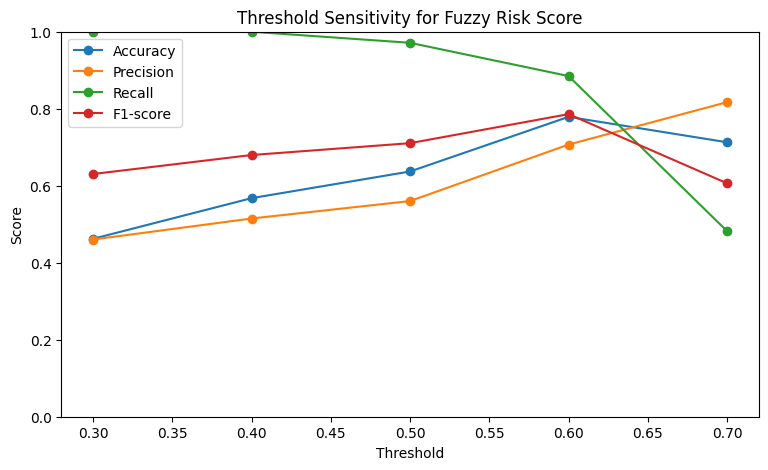

In [ ]:
plot_df = threshold_df.set_index("Threshold")

plot_df[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="line", marker="o", figsize=(9,5))
plt.title("Threshold Sensitivity for Fuzzy Risk Score")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

*The fuzzy rule-based system achieves competitive performance while remaining fully interpretable, demonstrating that meaningful predictive signal can be captured without relying on black-box models.*

# **Phase 6: Hybrid Model**

*In this phase, we integrate the fuzzy risk score into traditional machine learning models to form a hybrid system. The goal is to enhance predictive performance while preserving interpretability through the fuzzy component.*

In [ ]:
X_hybrid = df.drop(columns=["target"]).copy()

#Adding fuzzy score
X_hybrid["fuzzy_risk_score"] = df["fuzzy_risk_score"]
y = df["target"]

Here, the preprocessing pipeline is updated to include the fuzzy risk score as a numerical feature, ensuring that it is properly scaled along with other continuous variables.

In [ ]:
numerical_features_hybrid = ["age", "trestbps", "chol", "thalach", "oldpeak", "fuzzy_risk_score"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_hybrid = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features_hybrid),
    ("cat", categorical_transformer, categorical_features)
])

*We evaluate the same baseline classifiers using the hybrid feature set to assess whether the inclusion of fuzzy risk scores improves model performance.*

In [ ]:
hybrid_models = {
    "Logistic Regression (Hybrid)": Pipeline(steps=[
        ("preprocessor", preprocessor_hybrid),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Random Forest (Hybrid)": Pipeline(steps=[
        ("preprocessor", preprocessor_hybrid),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),

    "MLP (Hybrid)": Pipeline(steps=[
        ("preprocessor", preprocessor_hybrid),
        ("classifier", MLPClassifier(hidden_layer_sizes=(32,16), max_iter=1000, random_state=42))
    ])
}

*The hybrid models are evaluated using the same cross-validation strategy to ensure a fair comparison with the original baseline models.*

In [ ]:
hybrid_results = []

for model_name, model in hybrid_models.items():
    cv_results = cross_validate(
        model,
        X_hybrid,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    hybrid_results.append({
        "Model": model_name,
        "Accuracy": np.mean(cv_results["test_accuracy"]),
        "Precision": np.mean(cv_results["test_precision"]),
        "Recall": np.mean(cv_results["test_recall"]),
        "F1-score": np.mean(cv_results["test_f1"]),
        "ROC-AUC": np.mean(cv_results["test_roc_auc"])
    })

hybrid_df = pd.DataFrame(hybrid_results)
hybrid_df = hybrid_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

hybrid_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression (Hybrid),0.857978,0.874922,0.805026,0.836986,0.918338
1,Random Forest (Hybrid),0.838251,0.849413,0.791005,0.817431,0.909597
2,MLP (Hybrid),0.795082,0.783794,0.769048,0.772658,0.860096


*Comparing baseline vs hybrid*

In [ ]:
comparison_df = pd.concat([results_df, hybrid_df])
comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.854699,0.874430,0.797884,0.833226,0.918796
1,Random Forest,0.844918,0.857438,0.798413,0.825471,0.917428
2,MLP,0.795355,0.783679,0.769841,0.775092,0.858947
0,Logistic Regression (Hybrid),0.857978,0.874922,0.805026,0.836986,0.918338
1,Random Forest (Hybrid),0.838251,0.849413,0.791005,0.817431,0.909597
2,MLP (Hybrid),0.795082,0.783794,0.769048,0.772658,0.860096


In [ ]:
comparison_df = pd.concat([results_df, hybrid_df])

# Rename models for better readability
model_name_map = {
    "Logistic Regression": "LR",
    "Logistic Regression (Hybrid)": "LR Hybrid",
    "Random Forest": "RF",
    "Random Forest (Hybrid)": "RF Hybrid",
    "MLP": "MLP",
    "MLP (Hybrid)": "MLP Hybrid"
}
comparison_df["Model"] = comparison_df["Model"].replace(model_name_map)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LR,0.854699,0.874430,0.797884,0.833226,0.918796
1,RF,0.844918,0.857438,0.798413,0.825471,0.917428
2,MLP,0.795355,0.783679,0.769841,0.775092,0.858947
0,LR Hybrid,0.857978,0.874922,0.805026,0.836986,0.918338
1,RF Hybrid,0.838251,0.849413,0.791005,0.817431,0.909597
2,MLP Hybrid,0.795082,0.783794,0.769048,0.772658,0.860096


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# comparison_df_rounded = comparison_df.round(3)
# fig, ax = plt.subplots(figsize=(12, len(comparison_df_rounded) * 0.8))

# ax.xaxis.set_visible(False)
# ax.yaxis.set_visible(False)
# ax.set_frame_on(False)

# table = ax.table(cellText=comparison_df_rounded.values,
#                  colLabels=comparison_df_rounded.columns,
#                  loc='center',
#                  cellLoc='center')

# table.auto_set_font_size(False)
# table.set_fontsize(12)
# table.scale(1.2, 1.2)

# plt.title("Comparison of Baseline vs Hybrid Models (Table)", loc='center', fontsize=14)
# plt.tight_layout()
# plt.savefig('/content/drive/My Drive/comparisonbaselineVSHybrid.jpg', bbox_inches='tight')
# plt.show()

*The hybrid model preserves predictive performance while incorporating interpretable reasoning.*

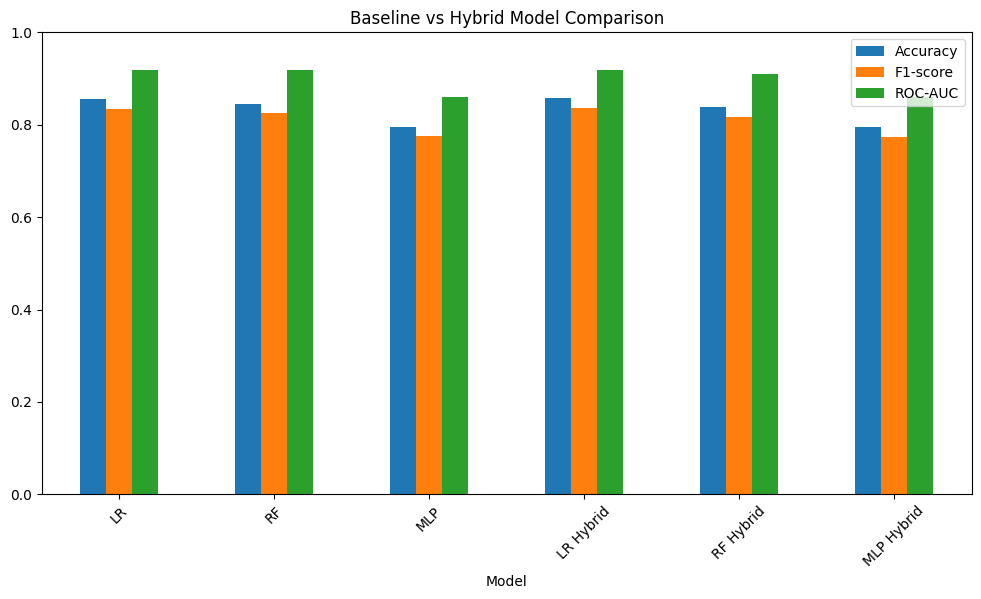

In [ ]:
import matplotlib.pyplot as plt

plot_df = comparison_df.set_index("Model")
plot_df[["Accuracy", "F1-score", "ROC-AUC"]].plot(kind="bar", figsize=(12,6))
plt.title("Baseline vs Hybrid Model Comparison")
plt.xticks(rotation=45)
plt.ylim(0, 1)
#  plt.savefig("/content/drive/My Drive/comparisonbaselineVSHybridimage.jpg")
plt.show()

*The hybrid modeling results indicate that incorporating the fuzzy risk score does not significantly improve predictive performance over strong baseline models such as Logistic Regression. However, the hybrid approach successfully preserves performance while introducing an interpretable reasoning layer. This demonstrates that explainable fuzzy logic can be integrated into machine learning pipelines without degrading model effectiveness, providing both transparency and competitive accuracy.*

# **Final Notes**

**Overall System Summary**

*This study presents a hybrid computational intelligence approach for heart disease prediction by combining a fuzzy rule-based system with traditional machine learning models. The fuzzy component was designed based on exploratory data analysis, translating key clinical indicators into interpretable linguistic rules. These rules were then used to generate a continuous fuzzy risk score, which was integrated into machine learning pipelines as an additional feature.*

**Key Findings**

*The experimental results demonstrate that baseline machine learning models, particularly Logistic Regression, achieve strong predictive performance on the dataset. The fuzzy rule-based system, while less accurate than optimized machine learning models, captures meaningful patterns and produces interpretable risk scores that align with domain knowledge. When integrated into hybrid models, the fuzzy risk score preserves overall performance while enhancing interpretability.*

**Interpretation of Hybrid Results**

*The hybrid modeling approach did not significantly outperform baseline models in terms of predictive accuracy or ROC-AUC. This outcome suggests that the fuzzy risk score largely encodes information already present in the original feature set. However, the key contribution of the hybrid system lies in its ability to maintain competitive performance while introducing an interpretable reasoning layer. This demonstrates that explainability can be incorporated into predictive systems without sacrificing effectiveness.*

**Why Fuzzy Matters**

*Unlike traditional machine learning models, the fuzzy system provides explicit reasoning through human-readable rules. For example, the system can explain predictions based on conditions such as high ST depression (oldpeak), low maximum heart rate (thalach), and abnormal clinical indicators. This transparency makes the system more suitable for decision-support scenarios where interpretability is critical, such as healthcare applications.*

**Strengths of the Proposed Approach**

*The proposed approach offers several advantages.*

1. *It integrates domain knowledge through fuzzy rules, enabling interpretable reasoning.*

2. *It produces a continuous risk score that can be directly used or incorporated into machine learning models.*

3. *It demonstrates that hybrid approaches can combine the strengths of rule-based systems and data-driven models.*

4. *The system maintains competitive performance while providing insights into the underlying decision process.*

**Limitations**

*Despite its strengths, the proposed system has several limitations.*

1. *The fuzzy rule base was manually designed and may not fully capture all complex relationships in the data.*

2. *Membership functions were defined heuristically rather than optimized through learning.*

3. *Additionally, the dataset size is relatively small, which may limit the generalizability of the results.*

**Future Work (Ideas)**

*Future work could focus on extending the system using neuro-fuzzy techniques, where membership functions and rules are learned directly from data. Optimization methods such as genetic algorithms or fuzzy clustering could also be applied to refine rule parameters. Additionally, the fuzzy risk score could be integrated into more advanced models or evaluated on larger and more diverse datasets to further validate its effectiveness.*

**Conclusion**

*In conclusion, this study demonstrates that interpretable fuzzy logic systems can be effectively combined with machine learning models to create hybrid predictive systems. While the fuzzy component alone does not outperform strong baseline models, it provides valuable interpretability and reasoning capabilities. The hybrid approach successfully preserves predictive performance while enhancing transparency, making it a promising direction for explainable artificial intelligence in healthcare applications.*